# Diana - E-Commerce Customer Churn Prediction System

## Abstract

#### **Introduction to the topic and motivation for the analysis**

Customer churn is the phenomenon where customers discontinue their relationship with a company or service. It represents one of the most significant challenges in the e-commerce industry, where customer retention is directly linked to long-term profitability and business sustainability. Acquiring new customers is considerably more expensive than retaining existing ones, making churn prediction a critical business objective for modern e-commerce platforms. As competition in online retail continues to increase, companies must leverage customer behavioral data to proactively identify users at risk of leaving the platform before churn occurs.



##### **Description of the purpose of the report**

This project aims to leverage machine learning and statistical analysis techniques to identify the primary factors influencing customer churn in an e-commerce environment. The objective is to build predictive models capable of accurately classifying customers at risk of leaving the platform while also uncovering behavioral and transactional patterns associated with customer attrition.


#### **Data used to perform the analysis**

The analysis was conducted using an e-commerce customer dataset containing demographic, behavioral, transactional, and engagement-related information. The dataset includes variables such as customer tenure, order frequency, satisfaction scores, cashback rewards, complaints, payment methods, order categories, and recent purchasing activity.

By analyzing both customer behavior and transactional engagement metrics, the project seeks to uncover actionable insights capable of supporting targeted retention strategies. These insights could help e-commerce companies proactively engage vulnerable customer segments, optimize customer support strategies, improve loyalty programs, and reduce long-term revenue loss.


#### **Problematique**

How can we accurately identify customers at risk of churning using behavioral and transactional e-commerce data?

#### **Proposed Methodolog**

1. Project Setup
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Statistical Analysis
5. Model Comparison and Evaluation


#### **Statistical Analysis**

The dataset contained several missing values in numerical behavioral variables such as tenure, warehouse-to-home distance, coupon usage, and recent ordering activity. These missing values were handled using median imputation due to the presence of skewed distributions and outliers.

Exploratory analysis revealed several important churn-related behavioral patterns, particularly involving complaints, tenure, recent purchasing activity, cashback rewards, satisfaction levels, and order frequency. Correlation analysis showed that customer churn is influenced by multiple interacting behavioral factors rather than a single dominant variable.

Statistical testing confirmed several significant differences between churned and retained customers:

* Complaint behavior showed a strong positive association with churn, indicating that customers who submitted complaints were substantially more likely to leave the platform.
* Customer tenure demonstrated the strongest negative relationship with churn, suggesting that long-term customers are significantly more loyal and retained.
* Recent order activity and cashback rewards were negatively correlated with churn, indicating that active and rewarded customers are less likely to leave.
* Customer engagement variables such as order frequency and satisfaction levels also displayed meaningful relationships with churn behavior.

Chi-square tests, t-tests, and Mann–Whitney U tests further confirmed statistically significant differences between churned and retained customer groups across several behavioral and transactional variables.


#### **Model Analyses**

Three machine learning classification models were implemented and compared:

* Logistic Regression
* Random Forest
* XGBoost

Logistic Regression served as an interpretable baseline model and achieved satisfactory overall performance with:

* Accuracy: ~88.7%
* Recall: ~53.7%
* ROC-AUC: ~0.885

Although the model provided reasonable predictive capability, its lower recall indicated limited effectiveness in identifying all churned customers.

Random Forest demonstrated significantly stronger predictive performance:

* Accuracy: ~97.6%
* Recall: ~86.3%
* ROC-AUC: ~0.999

The model effectively captured nonlinear behavioral relationships and substantially improved churn detection performance compared to Logistic Regression.

Among all evaluated models, XGBoost produced the strongest overall results:

* Accuracy: ~99.0%
* Recall: ~95.8%
* F1-score: ~0.971
* ROC-AUC: ~0.9995

The confusion matrix further confirmed the effectiveness of XGBoost, with only a very small number of churned customers incorrectly classified as retained customers.


#### **Conclusion**

The results demonstrate that customer churn in e-commerce environments is highly influenced by nonlinear behavioral and transactional interactions. Ensemble tree-based models, particularly XGBoost, proved exceptionally effective at capturing these complex relationships and significantly outperformed the baseline Logistic Regression model.

Overall, the project demonstrates that advanced machine learning techniques can provide highly accurate customer churn prediction systems capable of identifying at-risk customers before churn occurs. Such systems could enable e-commerce businesses to proactively optimize retention strategies, improve customer engagement, reduce revenue loss, and support data-driven decision-making processes.




## 1. Project Set Up

In [ ]:
# Imports
import numpy as np
import pandas as pd
import math

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning (scikit-learn)
import sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)



# Statistical Tests
# - let's see if we can get a better model by doing static analysis yay
from scipy.stats import ttest_ind, chi2_contingency, mannwhitneyu

In [ ]:
# data import
df = pd.read_excel('data/raw/ECommerceDataset2.xlsx')
df_stat_analisys = df.copy()
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [146]:
print("=" * 67)
print("THE FIRST 5 CUSTOMERS ")
print("=" * 67)
print(df.head())
print("\n")

print("=" * 67)
print("THE STATISTICAL METRICS FOR EACH ROW ")
print("=" * 67)

print(df.describe())
print("\n")

print("=" * 67)
print("ROW X COLS")
print("=" * 67)
print(df.shape)



# From here we can already decice what features we'll exclude
# starting with customerID
# also Churn will be our target
# features are to be determind


THE FIRST 5 CUSTOMERS 
   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN                Phone         1              8.0   
2       50003      1     NaN                Phone         1             30.0   
3       50004      1     0.0                Phone         3             15.0   
4       50005      1     0.0                Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male             2.0                         4   
4                   CC    Male             NaN                         3   

     PreferedOrderCat  SatisfactionScor

#### Data Dictionary

| Column | Description |
|--------|-------------|
| CustomerID | Unique customer ID |
| Churn | Churn Flag |
| Tenure | Tenure of customer in organization |
| PreferredLoginDevice | Preferred login device of customer |
| CityTier | City tier |
| WarehouseToHome | Distance in between warehouse to home of customer |
| PreferredPaymentMode | Preferred payment method of customer |
| Gender | Gender of customer |
| HourSpendOnApp | Number of hours spent on mobile application or website |
| NumberOfDeviceRegistered | Total number of devices registered on particular customer |
| PreferedOrderCat | Preferred order category of customer in last month |
| SatisfactionScore | Satisfactory score of customer on service |
| MaritalStatus | Marital status of customer |
| NumberOfAddress | Total number of addresses added on particular customer |
| Complain | Any complaint has been raised in last month |
| OrderAmountHikeFromlastYear | Percentage increase in order from last year |
| CouponUsed | Total number of coupons used in last month |
| OrderCount | Total number of orders placed in last month |
| DaySinceLastOrder | Days since last order by customer |
| CashbackAmount | Average cashback in last month |

In [147]:
# We clearly see all the collumn names and that there are a bunch of missing entries - to be handeled
print("=" * 67)
print("COLUMN NAMES")
print("=" * 67)

print(df.info())
print("\n")

print("=" * 67)
print("ANY MISSING ENTRIES?")
print("=" * 67)

print(df.isnull().sum())


COLUMN NAMES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  Numbe

## 2. EDA

In [148]:
sns.set_theme(style="whitegrid")

target_col = "Churn"

categorical_cols = [
    "PreferredLoginDevice",
    "CityTier",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "Complain"
]

numerical_cols = [
    "Tenure",
    "WarehouseToHome",
    "DaySinceLastOrder",
    "CashbackAmount"
]

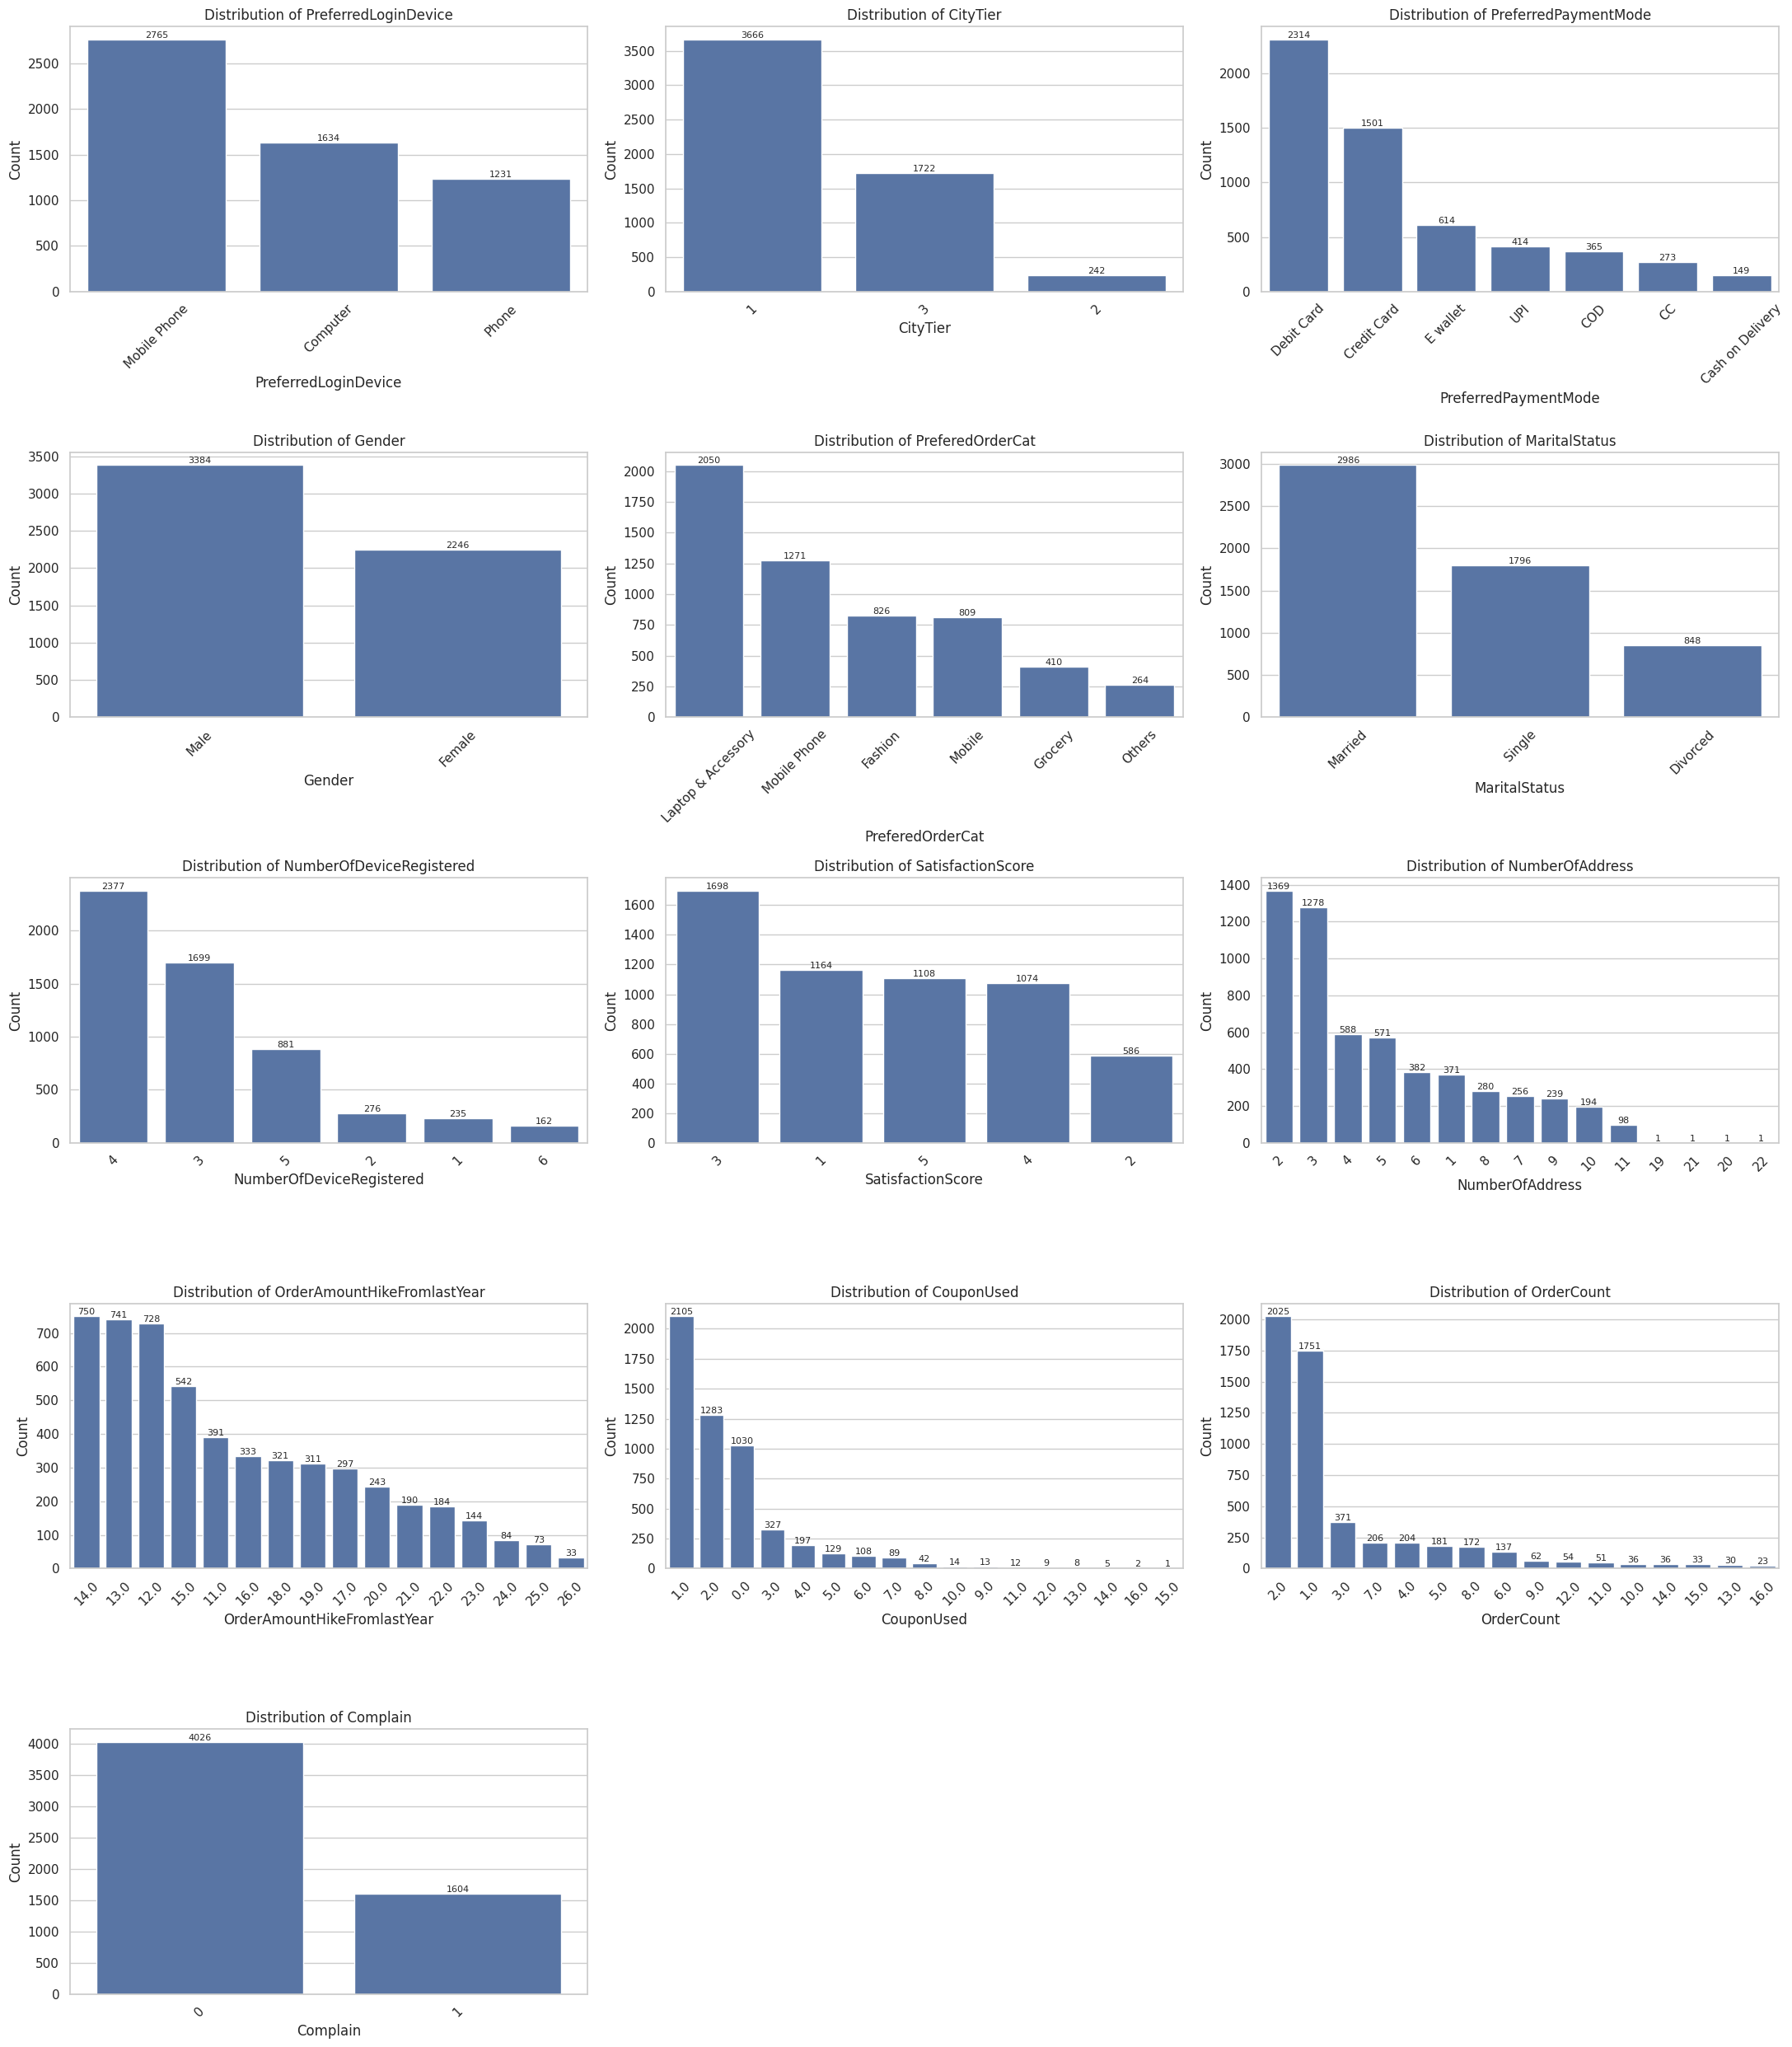

In [149]:
# Categorical data and bar charts with counts on bars - dynamic grid

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        ax=axes[i]
    )

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

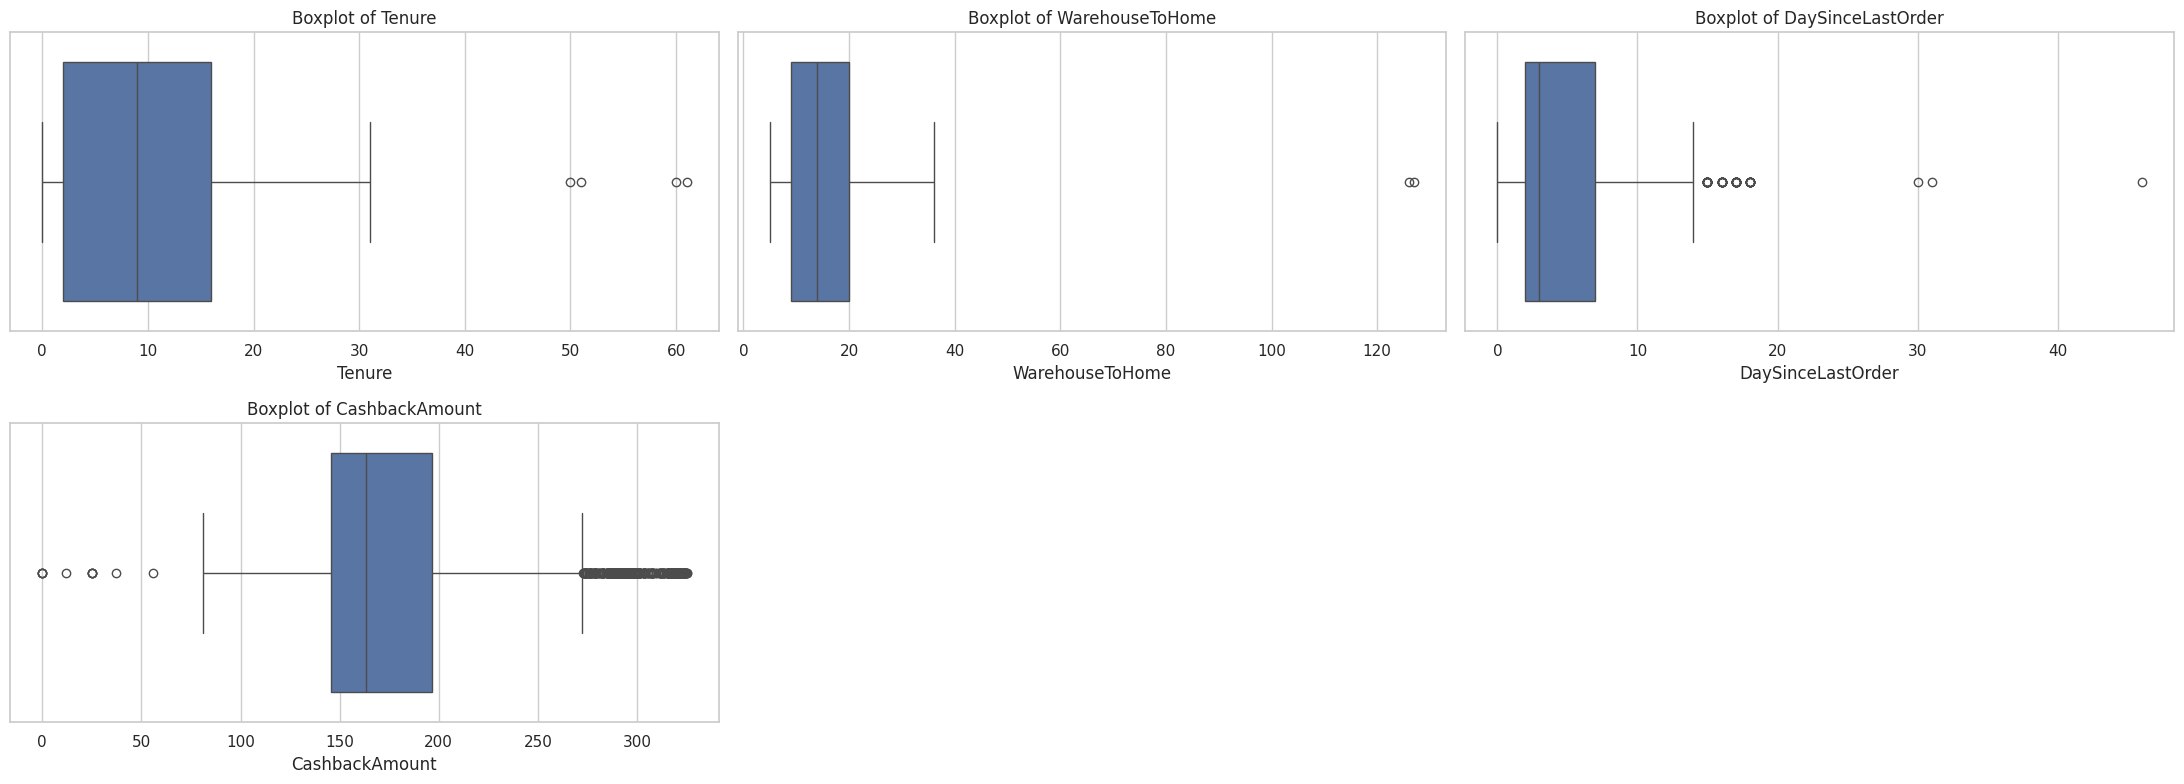

In [150]:
# Numerical data and box plots - dynamic grid

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])

    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

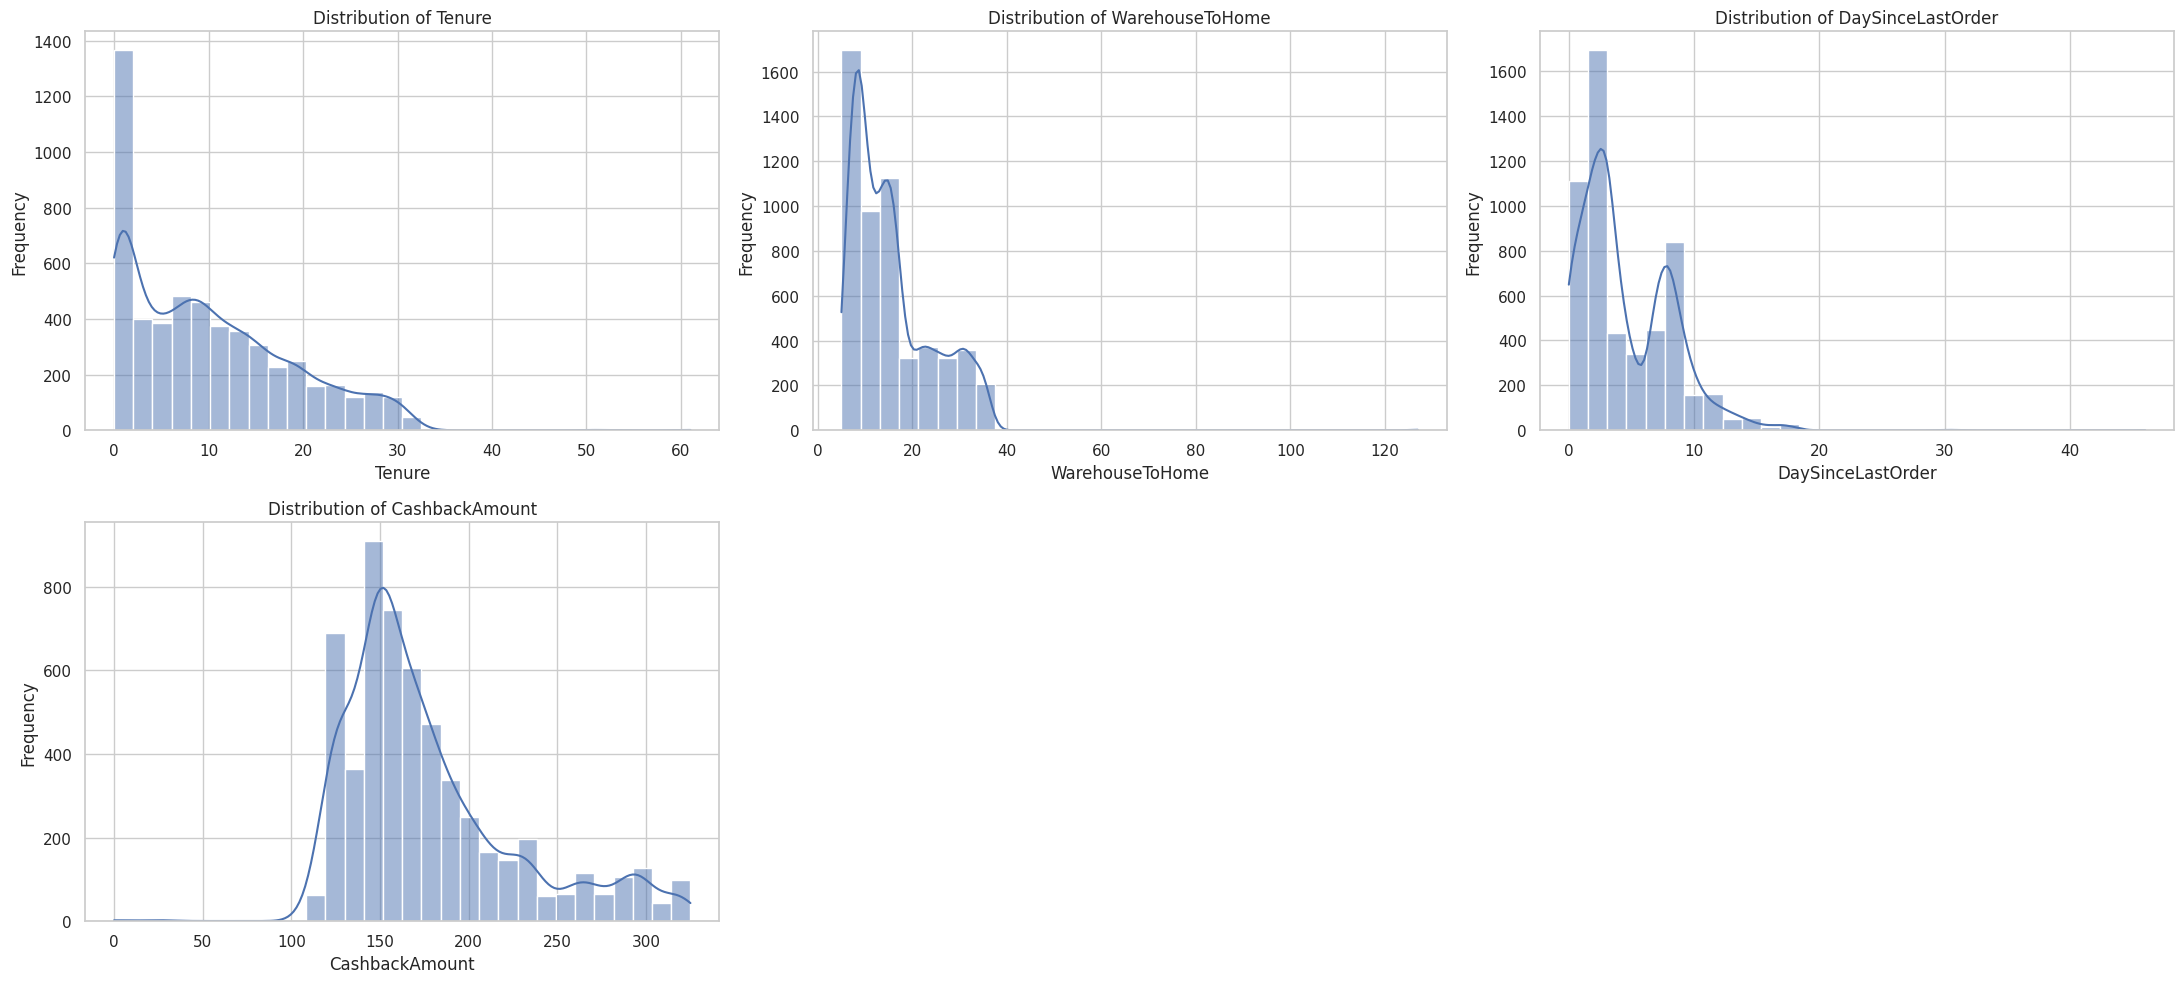

In [151]:
# Histograms for numeric data - dynamic grid

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

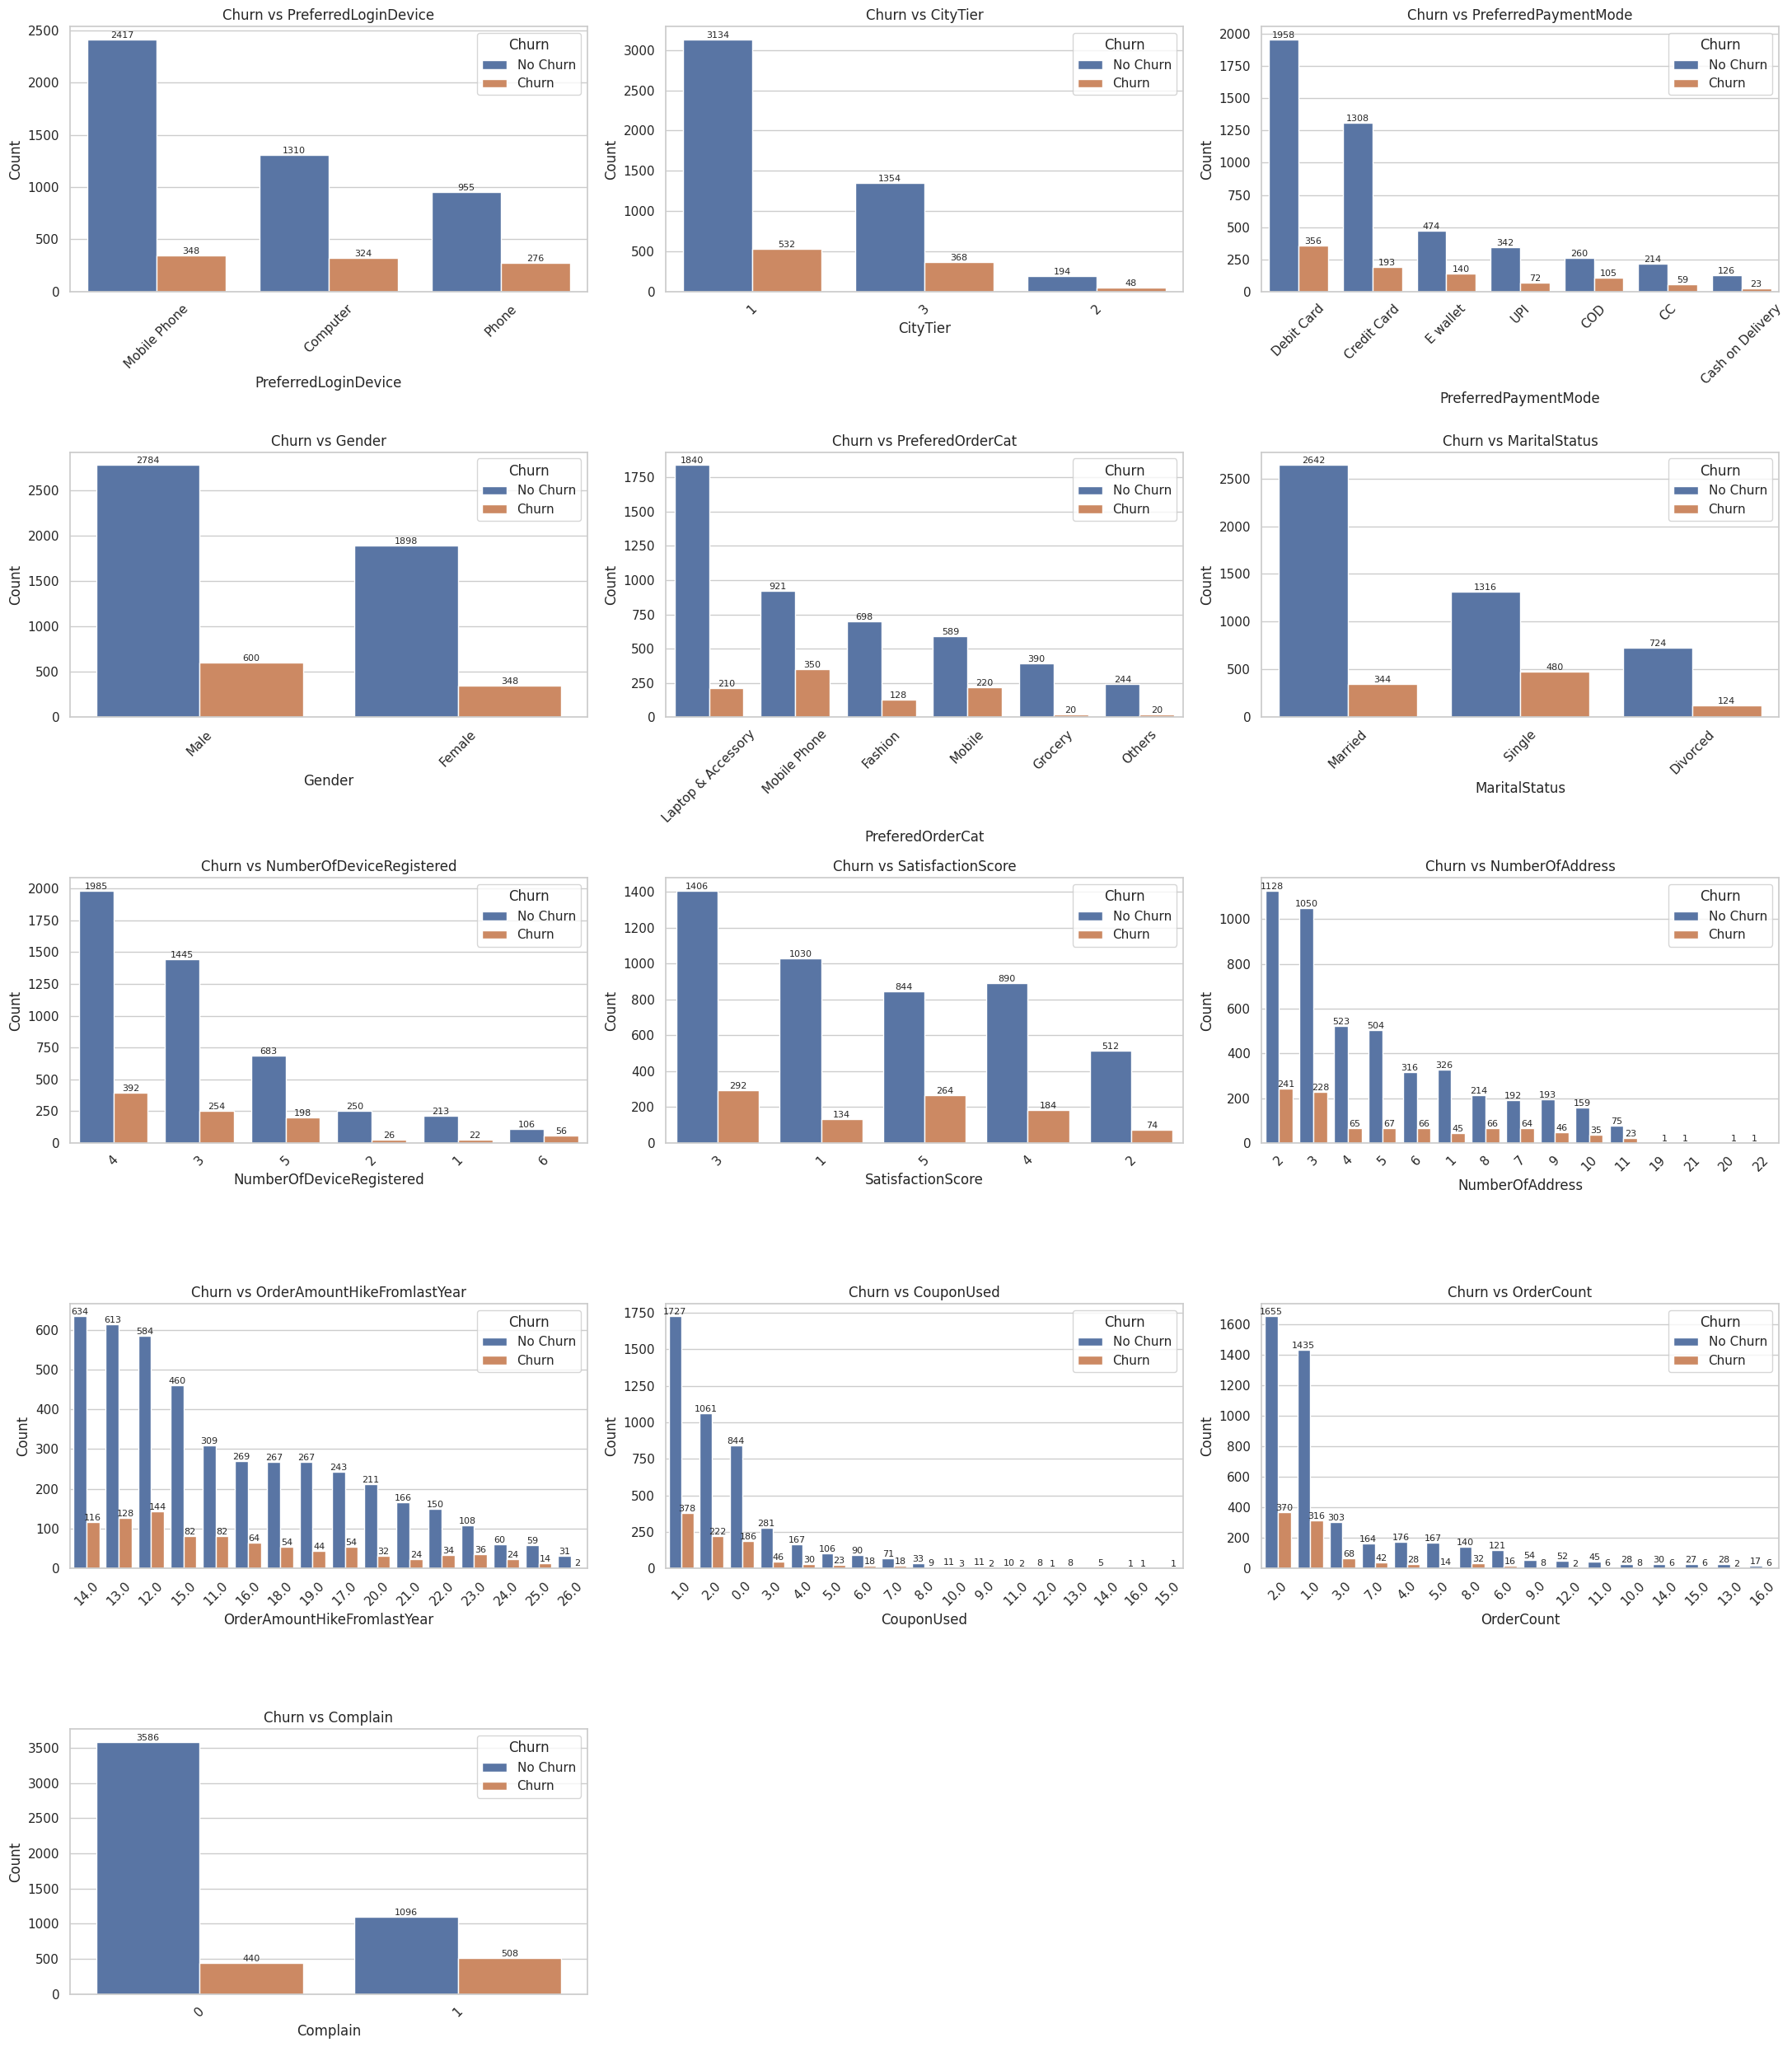

In [152]:
# Churn vs categorical variables with counts on bars - dynamic grid

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    ax = sns.countplot(
        data=df,
        x=col,
        hue=target_col,
        order=df[col].value_counts().index,
        ax=axes[i]
    )

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

    ax.set_title(f"Churn vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Churn", labels=["No Churn", "Churn"])

# Remove unused empty plots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Oberservations**:
* Most customers use mobile phones as their preferred login device.
* Preferred login device does not appear to strongly differentiate churn behavior. This suggests that the platform experience may be relatively consistent across devices.

* Most customers come from City Tier 1.
* Tier 3 customers show a relatively higher proportion of churn compared to Tier 1.
* Tier 2 contains far fewer customers overall.
* Customers from lower-tier cities may exhibit slightly higher churn tendencies, potentially due to differences in service quality, delivery experience, or purchasing power.


* Debit cards and credit cards are the dominant payment methods.
* E-wallet users appear to show relatively elevated churn.
* Cash on Delivery has comparatively low usage.
* Payment method may influence customer retention behavior. Digital payment users, particularly e-wallet customers, may represent a more price-sensitive or less loyal segment.

* Gender does not appear to be a strong standalone predictor of churn.


* Mobile Phone orders show a relatively high churn proportion.
* Laptop & Accessory customers have lower relative churn.
* Grocery customers appear highly retained.
* Customer churn varies across product categories. Mobile-related purchases may be associated with more transactional or short-term buying behavior, whereas grocery customers may exhibit stronger recurring engagement.

* Single customers may demonstrate lower long-term platform loyalty compared to married customers.


* Most customers have 3–4 registered devices.
* Customers with very high device counts appear to churn more frequently proportionally.
* Customers using multiple devices may exhibit more exploratory or less stable usage behavior, potentially increasing churn risk.

* Lower satisfaction scores generally correspond to higher churn.
* Satisfaction score 5 still contains churned users, but proportionally fewer.
* Customer satisfaction is strongly associated with churn behavior. Lower satisfaction levels are linked to increased probability of customer attrition.


* Most customers have few saved addresses.
* Customers with many addresses are relatively rare.
* Customers with more addresses may represent highly active or mobile users. However, the relationship with churn appears relatively weak overall.


* * Most customers cluster between 12–16.
* Churn appears relatively spread across values.
* The percentage increase in order amount from the previous year does not appear to create a very strong separation between churned and retained customers.

* Most customers use relatively few coupons.
* Churn decreases as coupon usage increases.
* Customers who actively use coupons appear more engaged with the platform and may therefore demonstrate stronger retention.

This may indicate:
* higher platform activity,
* loyalty behavior,
* or stronger responsiveness to promotions.


* Customers with very low order counts show substantially higher churn proportions.
* Customers with more orders are more likely to remain.

* Purchase frequency is strongly associated with customer retention. Customers with low order activity appear significantly more likely to churn.

* This is likely one of the strongest predictive variables.


* Customers who filed complaints exhibit dramatically higher churn rates.
* Among customers without complaints, churn is much lower.
* Complaint behavior is strongly associated with customer churn. Customers experiencing unresolved issues or dissatisfaction are substantially more likely to leave the platform.

* This feature will likely become one of the most important predictors in the machine learning model.






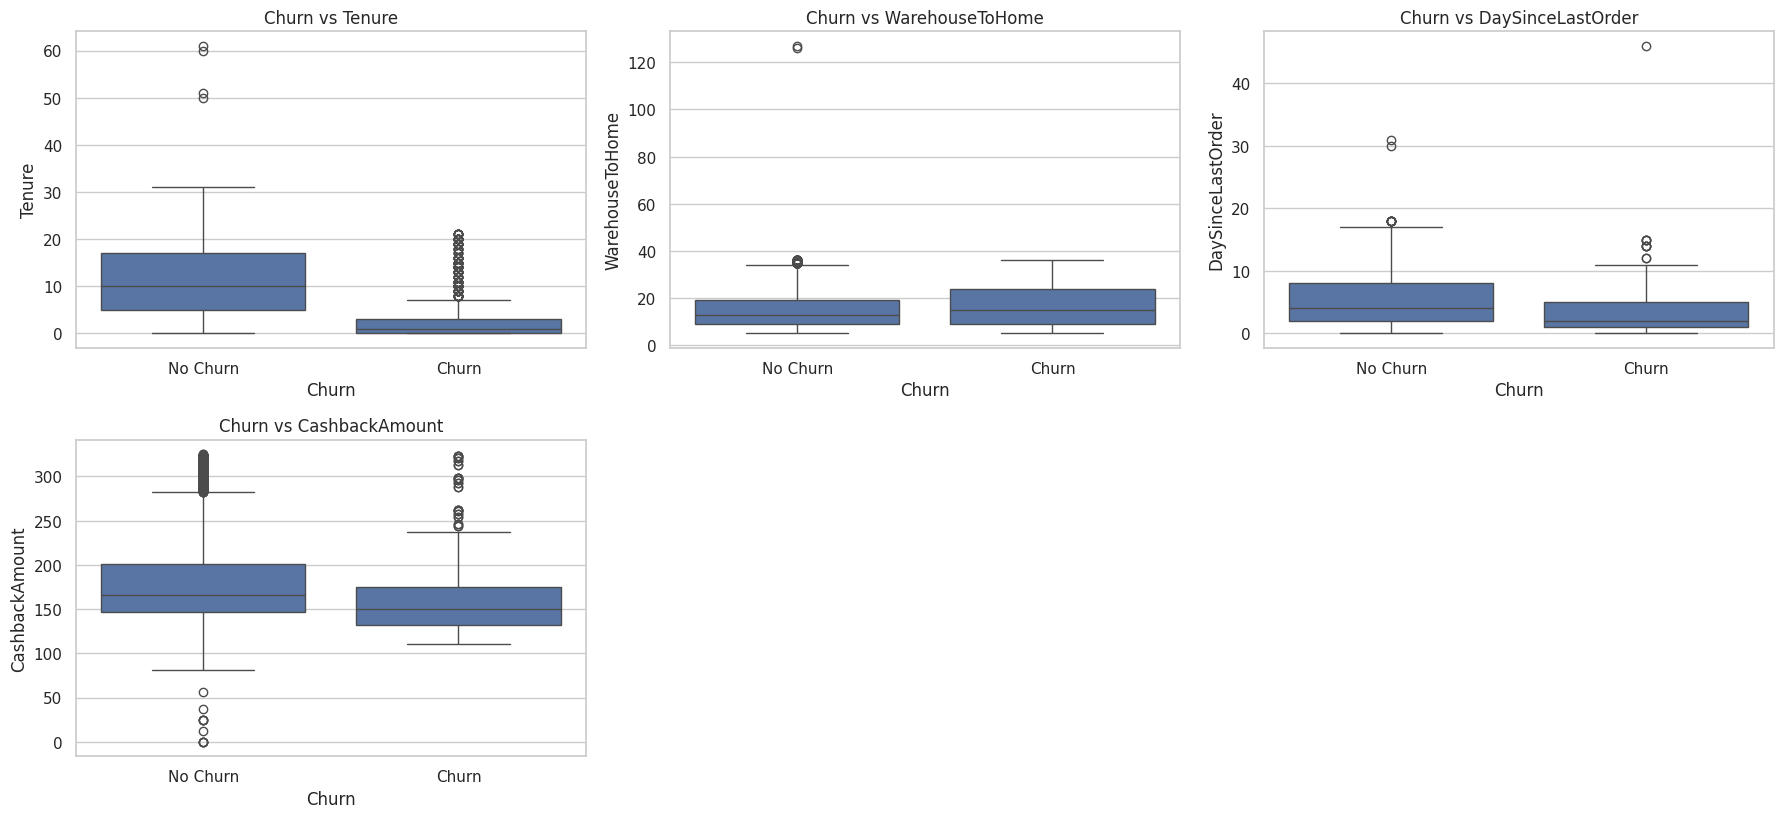

In [153]:
# Churn vs numerical variables - multiple plots in a grid

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):

    sns.boxplot(
        data=df,
        x=target_col,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"Churn vs {col}")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Churn", "Churn"])
# Remove empty subplot if needed
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

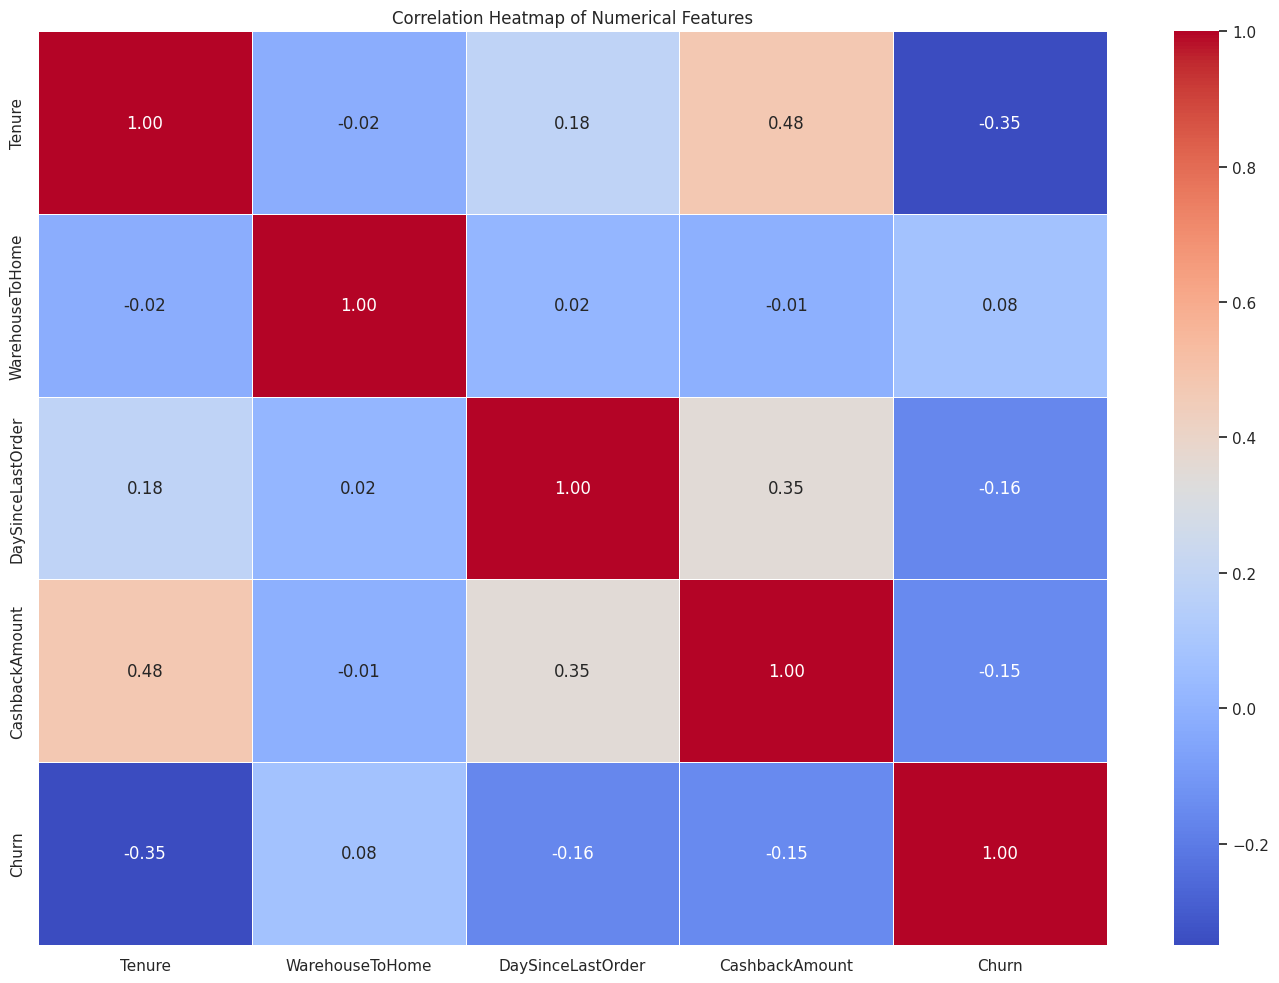

In [154]:
# Correlation heatmap
plt.figure(figsize=(14, 10))

corr = df[numerical_cols + [target_col]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## 3. Feature Engenering

### Handeling the numerical data

In [155]:
print(df[numerical_cols].isnull().sum())
df[numerical_cols].shape
df[numerical_cols].describe()

Tenure               264
WarehouseToHome      251
DaySinceLastOrder    307
CashbackAmount         0
dtype: int64


,Tenure,WarehouseToHome,DaySinceLastOrder,CashbackAmount
count,5366.000000,5379.000000,5323.000000,5630.000000
mean,10.189899,15.639896,4.543491,177.223030
std,8.557241,8.531475,3.654433,49.207036
min,0.000000,5.000000,0.000000,0.000000
25%,2.000000,9.000000,2.000000,145.770000
50%,9.000000,14.000000,3.000000,163.280000
75%,16.000000,20.000000,7.000000,196.392500
max,61.000000,127.000000,46.000000,324.990000


In [156]:
missing_cols = [
    "Tenure",
    "WarehouseToHome",
    "DaySinceLastOrder"
]

for col in missing_cols:
    df[col] = df[col].fillna(df[col].median())
print(df[numerical_cols].isnull().sum())
df[numerical_cols].shape
df[numerical_cols].describe()

Tenure               0
WarehouseToHome      0
DaySinceLastOrder    0
CashbackAmount       0
dtype: int64


,Tenure,WarehouseToHome,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000
mean,10.134103,15.566785,4.459325,177.223030
std,8.357951,8.345961,3.570626,49.207036
min,0.000000,5.000000,0.000000,0.000000
25%,3.000000,9.000000,2.000000,145.770000
50%,9.000000,14.000000,3.000000,163.280000
75%,15.000000,20.000000,7.000000,196.392500
max,61.000000,127.000000,46.000000,324.990000


Obeservations:
* we handelled the missing values by, adding the median, where the value was missing, as we can see the mean and std,didn't change too much


### Handeling the categorical data

##### Dupplicates

In [157]:
# Detailed category overview
for col in categorical_cols:
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"Number of categories: {df[col].nunique()}")
    print(f"{'='*40}")

    print(df[col].value_counts())



Column: PreferredLoginDevice
Number of categories: 3
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

Column: CityTier
Number of categories: 3
CityTier
1    3666
3    1722
2     242
Name: count, dtype: int64

Column: PreferredPaymentMode
Number of categories: 7
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Column: Gender
Number of categories: 2
Gender
Male      3384
Female    2246
Name: count, dtype: int64

Column: PreferedOrderCat
Number of categories: 6
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

Column: MaritalStatus
Number of categories: 3
MaritalStatus
Married     2986
Single      1796


In [158]:
# Group / clean categorical and discrete columns

# 1. PreferredLoginDevice
df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({
    "Mobile Phone": "Mobile",
    "Phone": "Mobile"
})

# 2. PreferredPaymentMode
df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({
    "CC": "Credit Card",
    "COD": "Cash on Delivery"
})

# 3. PreferedOrderCat
df["PreferedOrderCat"] = df["PreferedOrderCat"].replace({
    "Mobile Phone": "Mobile"
})

# 4. NumberOfAddress grouped
df["AddressGroup"] = pd.cut(
    df["NumberOfAddress"],
    bins=[0, 3, 6, 10, 100],
    labels=["1-3", "4-6", "7-10", "11+"]
)

# 5. CouponUsed grouped
df["CouponGroup"] = pd.cut(
    df["CouponUsed"],
    bins=[-1, 0, 2, 5, 100],
    labels=["0", "1-2", "3-5", "6+"]
)

# 6. OrderCount grouped
df["OrderCountGroup"] = pd.cut(
    df["OrderCount"],
    bins=[0, 2, 5, 10, 100],
    labels=["1-2", "3-5", "6-10", "11+"]
)

# Check new category distributions
grouped_cols = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "PreferedOrderCat",
    "AddressGroup",
    "CouponGroup",
    "OrderCountGroup"
]

for col in grouped_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== PreferredLoginDevice =====
PreferredLoginDevice
Mobile      3996
Computer    1634
Name: count, dtype: int64

===== PreferredPaymentMode =====
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

===== PreferedOrderCat =====
PreferedOrderCat
Mobile                2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64

===== AddressGroup =====
AddressGroup
1-3     3018
4-6     1541
7-10     969
11+      102
Name: count, dtype: int64

===== CouponGroup =====
CouponGroup
1-2    3388
0      1030
3-5     653
6+      303
NaN     256
Name: count, dtype: int64

===== OrderCountGroup =====
OrderCountGroup
1-2     3776
3-5      756
6-10     613
NaN      258
11+      227
Name: count, dtype: int64


#### Missing values

In [159]:
print(df[categorical_cols].isnull().sum())

PreferredLoginDevice             0
CityTier                         0
PreferredPaymentMode             0
Gender                           0
PreferedOrderCat                 0
MaritalStatus                    0
NumberOfDeviceRegistered         0
SatisfactionScore                0
NumberOfAddress                  0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
Complain                         0
dtype: int64


In [160]:
missing_discrete_cols = [
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount"
]

for col in missing_discrete_cols:
    df[col] = df[col].fillna(df[col].median())

df[missing_discrete_cols].isnull().sum()

,0
OrderAmountHikeFromlastYear,0
CouponUsed,0
OrderCount,0


In [161]:
df["CouponGroup"] = pd.cut(
    df["CouponUsed"],
    bins=[-1, 0, 2, 5, 100],
    labels=["0", "1-2", "3-5", "6+"]
)

df["OrderCountGroup"] = pd.cut(
    df["OrderCount"],
    bins=[0, 2, 5, 10, 100],
    labels=["1-2", "3-5", "6-10", "11+"]
)

df["OrderAmountHikeGroup"] = pd.cut(
    df["OrderAmountHikeFromlastYear"],
    bins=[0, 12, 16, 20, 100],
    labels=["Low", "Medium", "High", "Very High"]
)

# Missing values in discrete behavioral variables were imputed using the median
#because these variables are skewed and contain outliers.
#Grouped versions were then created to make category-level EDA easier to interpret.

categorical_cols_grouped = [
    "PreferredLoginDevice",
    "CityTier",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "AddressGroup",
    "OrderAmountHikeGroup",
    "CouponGroup",
    "OrderCountGroup",
    "Complain"
]

In [162]:
# =========================================================
# HANDLE REMAINING MISSING VALUES
# =========================================================
df_model = df.copy()

# Check missing values before imputation
print("Missing values before imputation:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

# Fill numeric columns with median
numeric_cols = df_model.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Fill categorical columns with mode
categorical_cols_model = df_model.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols_model:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

# Verify missing values are gone
print("\nMissing values after imputation:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Missing values before imputation:
HourSpendOnApp    255
dtype: int64

Missing values after imputation:
Series([], dtype: int64)


In [163]:
# =========================================================
# DROP ID COLUMN
# =========================================================

if "CustomerID" in df_model.columns:
    df_model = df_model.drop("CustomerID", axis=1)

## 4. Statitical Analysis

In [ ]:
# T-Test


numerical_test_cols = [
    "Tenure",
    "WarehouseToHome",
    "DaySinceLastOrder",
    "CashbackAmount"
]

for col in numerical_test_cols:

    churn_0 = df[df["Churn"] == 0][col]
    churn_1 = df[df["Churn"] == 1][col]

    stat, p = ttest_ind(churn_0, churn_1)

    print(f"\n===== {col} =====")
    print(f"T-statistic: {stat:.4f}")
    print(f"P-value: {p:.6f}")

    if p < 0.05:
        print("Significant difference between churn groups")
    else:
        print("No significant difference")


===== Tenure =====
T-statistic: 26.9272
P-value: 0.000000
Significant difference between churn groups

===== WarehouseToHome =====
T-statistic: -5.2298
P-value: 0.000000
Significant difference between churn groups

===== DaySinceLastOrder =====
T-statistic: 11.8381
P-value: 0.000000
Significant difference between churn groups

===== CashbackAmount =====
T-statistic: 11.7018
P-value: 0.000000
Significant difference between churn groups


In [ ]:
# Chi Squared test

categorical_test_cols = [
    "PreferredPaymentMode",
    "PreferedOrderCat",
    "MaritalStatus",
    "Complain"
]

for col in categorical_test_cols:

    contingency_table = pd.crosstab(df[col], df["Churn"])

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print(f"\n===== {col} =====")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"P-value: {p:.6f}")

    if p < 0.05:
        print("Significant association with churn")
    else:
        print("No significant association")


===== PreferredPaymentMode =====
Chi-square statistic: 51.8290
P-value: 0.000000
Significant association with churn

===== PreferedOrderCat =====
Chi-square statistic: 288.5978
P-value: 0.000000
Significant association with churn

===== MaritalStatus =====
Chi-square statistic: 188.6710
P-value: 0.000000
Significant association with churn

===== Complain =====
Chi-square statistic: 350.9255
P-value: 0.000000
Significant association with churn


In [ ]:
# Mann-Whitney U Test


mw_cols = [
    "CashbackAmount",
    "DaySinceLastOrder",
    "WarehouseToHome",
    "OrderCount"
]

for col in mw_cols:

    churn_0 = df[df["Churn"] == 0][col]
    churn_1 = df[df["Churn"] == 1][col]

    stat, p = mannwhitneyu(churn_0, churn_1)

    print(f"\n===== {col} =====")
    print(f"Mann-Whitney U statistic: {stat:.4f}")
    print(f"P-value: {p:.6f}")

    if p < 0.05:
        print("Significant distribution difference")
    else:
        print("No significant difference")



===== CashbackAmount =====
Mann-Whitney U statistic: 2810031.0000
P-value: 0.000000
Significant distribution difference

===== DaySinceLastOrder =====
Mann-Whitney U statistic: 2831473.0000
P-value: 0.000000
Significant distribution difference

===== WarehouseToHome =====
Mann-Whitney U statistic: 1946192.5000
P-value: 0.000000
Significant distribution difference

===== OrderCount =====
Mann-Whitney U statistic: 2313084.0000
P-value: 0.030500
Significant distribution difference


In [167]:
# Correlation Analysis
corr_with_churn = df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

print(corr_with_churn)

Churn                          1.000000
Complain                       0.250188
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.069544
NumberOfAddress                0.043931
HourSpendOnApp                 0.018675
CouponUsed                    -0.001430
OrderAmountHikeFromlastYear   -0.007075
CustomerID                    -0.019083
OrderCount                    -0.024038
CashbackAmount                -0.154118
DaySinceLastOrder             -0.155871
Tenure                        -0.337831
Name: Churn, dtype: float64


**Observation :** Correlation analysis revealed that customer complaints, shorter tenure, lower cashback rewards, and lower recent activity are among the strongest factors associated with churn. Complaint behavior exhibited the strongest positive relationship with churn, while tenure demonstrated the strongest negative relationship, indicating that long-term customers are substantially more likely to remain loyal to the platform. Most other variables displayed relatively weak individual correlations, suggesting that churn behavior is influenced by multiple interacting behavioral factors rather than a single dominant predictor.

## 5. Model Comparison

In [ ]:
# =========================================================
# CHURN PREDICTION - MODEL COMPARISON
# Logistic Regression vs Random Forest vs XGBoost
# =========================================================

# =========================================================
# COPY DATAFRAME
# =========================================================

df_model = df.copy()

# =========================================================
# DROP ID COLUMN
# =========================================================

if "CustomerID" in df_model.columns:
    df_model = df_model.drop("CustomerID", axis=1)

# =========================================================
# HANDLE MISSING VALUES
# =========================================================

numeric_cols = df_model.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

categorical_cols_model = df_model.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols_model:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

print("Remaining missing values:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

# =========================================================
# ONE-HOT ENCODING
# =========================================================

df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

# Convert boolean dummy columns to integers
df_model = df_model.astype(int)

# =========================================================
# FEATURES / TARGET
# =========================================================

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# SCALING ONLY FOR LOGISTIC REGRESSION
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# MODELS
# =========================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

# =========================================================
# TRAIN + EVALUATE
# =========================================================

results = []

for name, model in models.items():

    print("\n" + "="*60)
    print(name)
    print("="*60)

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# =========================================================
# FINAL RESULTS TABLE
# =========================================================

results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

display(results_df.sort_values(by="ROC-AUC", ascending=False))

Remaining missing values:
Series([], dtype: int64)

Logistic Regression
Accuracy : 0.8872
Precision: 0.7234
Recall   : 0.5368
F1 Score : 0.6163
ROC-AUC  : 0.8850

Confusion Matrix:
[[897  39]
 [ 88 102]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       936
           1       0.72      0.54      0.62       190

    accuracy                           0.89      1126
   macro avg       0.82      0.75      0.78      1126
weighted avg       0.88      0.89      0.88      1126


Random Forest
Accuracy : 0.9760
Precision: 0.9939
Recall   : 0.8632
F1 Score : 0.9239
ROC-AUC  : 0.9991

Confusion Matrix:
[[935   1]
 [ 26 164]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       936
           1       0.99      0.86      0.92       190

    accuracy                           0.98      1126
   macro avg       0.98      0.93      0.95      1126
we

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.990231,0.983784,0.957895,0.970667,0.999477
1,Random Forest,0.976021,0.993939,0.863158,0.923944,0.999069
0,Logistic Regression,0.887211,0.723404,0.536842,0.616314,0.884992


**observation :** The results demonstrate a clear performance difference between the three evaluated classification models. Logistic Regression was first implemented as a baseline model due to its simplicity and interpretability. Although it achieved a reasonable ROC-AUC score of 0.885 and an accuracy of 88.7%, its recall score of 53.7% indicates that a substantial proportion of churned customers were not correctly identified. Since customer churn prediction prioritizes detecting at-risk customers, this lower recall limits the effectiveness of Logistic Regression for practical retention strategies.

The Random Forest model significantly improved predictive performance across all evaluation metrics. With an accuracy of 97.6%, an F1-score of 0.924, and a ROC-AUC score of 0.9991, the model demonstrated a much stronger ability to capture the nonlinear relationships and behavioral interactions present in the dataset. The model also achieved very high precision while substantially increasing recall compared to Logistic Regression, indicating a far more balanced classification performance.

Among all tested models, XGBoost produced the best overall results. The model achieved an accuracy of 99.0%, a recall of 95.8%, an F1-score of 0.971, and the highest ROC-AUC score of 0.9995. The confusion matrix further confirms the model’s effectiveness, with only 8 churned customers incorrectly classified as non-churners. This demonstrates an exceptional ability to identify customers at risk of leaving the platform while maintaining extremely high overall classification accuracy.

The superior performance of the ensemble tree-based methods, particularly XGBoost, aligns with the findings from the exploratory data analysis and statistical analysis. Earlier analysis showed that churn behavior was influenced by multiple interacting behavioral factors, including complaints, tenure, recent activity, cashback rewards, and customer engagement. These relationships were often nonlinear and weakly correlated individually, making tree-based boosting methods especially suitable for the problem.

Overall, the project demonstrates that customer churn can be predicted with very high accuracy using advanced ensemble machine learning techniques. XGBoost emerged as the most effective model due to its strong capability to capture complex nonlinear patterns and interactions within customer behavior data. These results suggest that machine learning-driven churn prediction systems could provide significant business value by enabling early identification of at-risk customers and supporting proactive retention strategies.

##
